C:\Users\user\AppData\Local\Temp\ipykernel_16164\3580364447.py:7: DtypeWarning: Columns (41,42,44,45) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r'D:\PYTHON PROJECTS\INDIAN SAMARTPHONE SALES MARKET\CLEANED DATASETS\Main_order_data.csv',encoding='latin1')
C:\Users\user\AppData\Local\Temp\ipykernel_16164\3580364447.py:9: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['order_date'] = pd.to_datetime(df['order_date'])
C:\Users\user\AppData\Local\Temp\ipykernel_16164\3580364447.py:63: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mom_growth = df.groupby('order_month_name').agg({'Total Bill':'sum'}).reset_index()
C:\Users\user\AppData\Loc

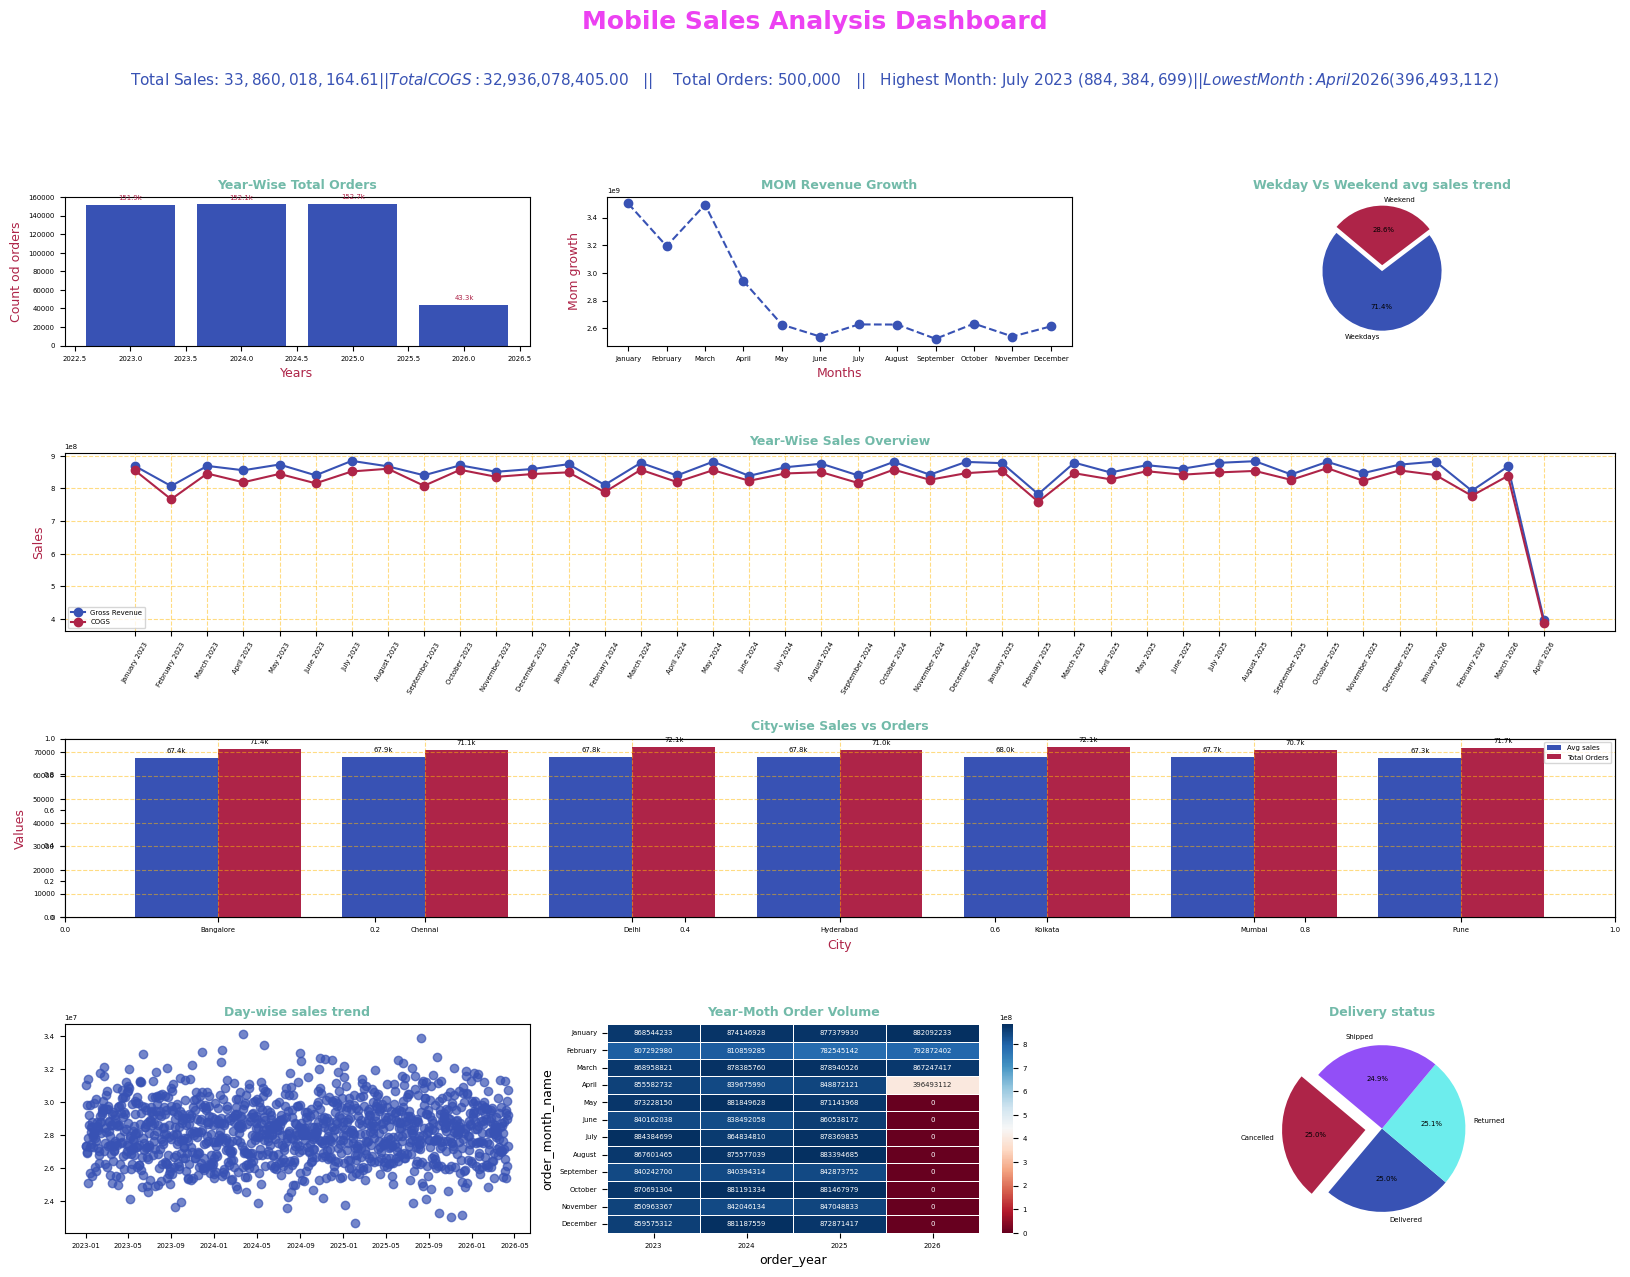

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

df = pd.read_csv(r'D:\PYTHON PROJECTS\INDIAN SAMARTPHONE SALES MARKET\CLEANED DATASETS\Main_order_data.csv',encoding='latin1')

df['order_date'] = pd.to_datetime(df['order_date'])

df['order_weekday'] = df['order_date'].dt.day_of_week
df['order_day_name'] = df['order_date'].dt.day_name()
df['order_month_name'] = df['order_date'].dt.month_name()
df['order_year'] = df['order_date'].dt.year
df['order_month_year'] = df['order_month_name']+' '+df['order_year'].astype(str)

# print(df.head(30))
# print(df.info())

# structure day & month
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
df['order_day_name'] = pd.Categorical(df['order_day_name'],categories=day_order,ordered=True)
df['order_month_name'] = pd.Categorical(df['order_month_name'],categories=month_order,ordered=True)

# Dashboard design
plt.rcParams.update({
    'font.size': 5,
    'axes.titlesize': 9,
    'axes.labelsize': 9
})

fig = plt.figure(figsize=(20,14))
gs = gridspec.GridSpec(
    4, 6,
    figure=fig,
    hspace=0.6,
    wspace=0.4,
    height_ratios=[1, 1.2, 1.2, 1.4]
)


# 1-year wise total orders
total_orders = df.groupby('order_year').size().reset_index(name='count_of_orders')
# print(total_orders)

x1 = total_orders['order_year']
y1 = total_orders['count_of_orders']


ax1 = fig.add_subplot(gs[0,0:2])

ax1_bars = ax1.bar(x1,y1,color='#3852B4')
ax1_label = [f'{v/1000:.1f}k' for v in y1]
ax1.bar_label(ax1_bars,labels=ax1_label,padding=3,color='#AE2448')
ax1.set_xlabel('Years',color='#AE2448')
ax1.set_ylabel('Count od orders',color='#AE2448')
ax1.set_title('Year-Wise Total Orders',fontweight='bold',color='#72BAA9')


# 2-Mom wise growth
mom_growth = df.groupby('order_month_name').agg({'Total Bill':'sum'}).reset_index()
mom_growth['mom_growth'] = mom_growth['Total Bill'].pct_change()*100
mom_growth['mom_growth'] = mom_growth['mom_growth'].fillna(0)
# print(mom_growth)

x2 = mom_growth['order_month_name']
y2 = mom_growth['Total Bill']
z3 = mom_growth['mom_growth']

ax2 = fig.add_subplot(gs[0,2:4])

ax2.plot(x2,y2,color='#3852B4',marker='o',linestyle='--')
ax2.set_xlabel('Months',color='#AE2448')
ax2.set_ylabel('Mom growth',color='#AE2448')
ax2.set_title('MOM Revenue Growth',fontweight='bold',color='#72BAA9')


# 3-Weekdays Vs Weekend order trend(pie chart)
def day_type(x):
    if x<5:
        return 'weekdays'
    else:
        return 'weekend'
    
df['day_type'] = df['order_weekday'].apply(day_type)

weekday_trend = df.groupby('day_type').agg({'order_id':'count'}).reset_index()
# print(weekday_trend)

ax3 =fig.add_subplot(gs[0,4:6])

x3 = weekday_trend['order_id']
y3 = ['Weekdays','Weekend']
ax3_col = ['#3852B4','#AE2448']

ax3_explode = [0,0.1]

ax3.pie(x3,labels=y3,colors=ax3_col,explode=ax3_explode,autopct='%1.1f%%',startangle=140)
ax3.set_title('Wekday Vs Weekend avg sales trend',fontweight='bold',color='#72BAA9')


# 4-month-year wise overview(line chart)
# Create COGS
df['cogs'] = df['unit_price'] * df['quantity']

# Create proper datetime
df['order_date_temp'] = pd.to_datetime(
    df['order_year'].astype(str) + '-' + df['order_month_name'].astype(str),
    format='%Y-%B',
    errors='coerce'
)

# Group
mt_yr_ov = df.groupby(
    ['order_month_year','order_date_temp']
).agg({
    'Total Bill':'sum',
    'cogs':'sum'
}).reset_index()

# Sort
mt_yr_ov = mt_yr_ov.sort_values('order_date_temp')

# Plot
ax4 = fig.add_subplot(gs[1,:])

ax4.plot(mt_yr_ov['order_month_year'], mt_yr_ov['Total Bill'],
         label='Gross Revenue', marker='o', color='#3852B4')

ax4.plot(mt_yr_ov['order_month_year'], mt_yr_ov['cogs'],
         label='COGS', marker='o', color='#AE2448')

ax4.set_ylabel('Sales', color='#AE2448')
ax4.tick_params(axis='x', rotation=60)
ax4.grid(axis='both', linestyle='--', alpha=0.5, color='#ffba08')
ax4.set_title('Year-Wise Sales Overview', fontweight='bold', color='#72BAA9')
ax4.legend(loc='lower left')


# 5-city wise avg sales & orders 
city_sales = df.groupby('city').agg({'Total Bill':'mean','order_id':'count'}).reset_index()
# print(city_sales)

x5 = city_sales['city']
y5 = city_sales['Total Bill']
z5 = city_sales['order_id']

ax5 = fig.add_subplot(gs[2,:])

x_pos = np.arange(len(x5))   # numeric positions
width = 0.4

ax5 = fig.add_subplot(gs[2,:])

ax5_bar1 = ax5.bar(x_pos - width/2, y5, width, color='#3852B4', label='Avg sales')
ax5_bar2 = ax5.bar(x_pos + width/2, z5, width, color='#AE2448', label='Total Orders')
ax5_label1 = [f'{v/1000:.1f}k' for v in y5]
ax5_label2 = [f'{v/1000:.1f}k' for v in z5]
ax5.bar_label(ax5_bar1, labels=ax5_label1, padding=3)
ax5.bar_label(ax5_bar2, labels=ax5_label2, padding=3)
ax5.set_xticks(x_pos)
ax5.set_xticklabels(x5)
ax5.set_xlabel('City', color='#AE2448')
ax5.set_ylabel('Values', color='#AE2448')
ax5.set_title('City-wise Sales vs Orders', fontweight='bold', color='#72BAA9')
ax5.grid(axis='both', linestyle='--', alpha=0.5,color='#ffba08')
ax5.legend()


# 6-Day-wise wise revenue trend (scatter)
mt_rev = df.groupby('order_date').agg({'Total Bill':'sum'}).reset_index()
# print(mt_rev)

x6 = mt_rev['order_date']
y6 = mt_rev['Total Bill']

ax6 = fig.add_subplot(gs[3,0:2])

ax6.scatter(x6,y6,color='#3852B4',alpha=0.7)
ax6.set_title('Day-wise sales trend',fontweight='bold', color='#72BAA9')


# 7-Year moth revenue(heatmap)
yr_mt_rev = df.pivot_table(index='order_month_name',columns='order_year',values='Total Bill',aggfunc='sum')
# print(yr_mt_rev)

ax7 = fig.add_subplot(gs[3,2:4])

sns.heatmap(
    yr_mt_rev,
    annot=True,         
    fmt='.0f',            
    linewidths=0.5,
    cmap='RdBu'         
)

ax7.set_title('Year-Moth Order Volume', fontweight='bold',color='#72BAA9')


# 8-Order delivery status(pie)
delivery_status = df.groupby('order_status').size().reset_index(name='count')
# print(delivery_status)

ax8 = fig.add_subplot(gs[3,4:6])

x8 = delivery_status['count']
ax8_label = list(delivery_status['order_status'])
ax8_col = ['#AE2448','#3852B4','#6DEDED','#924FF7']

ax8_explode = [0.2,0,0,0]

ax8.pie(x8,labels=ax8_label,colors=ax8_col,explode=ax8_explode,autopct='%1.1f%%',startangle=140)
ax8.set_title('Delivery status',fontweight='bold',color='#72BAA9')


# KPI
Total_revenue = df['Total Bill'].sum()
Total_cogs = df['cogs'].sum()
Total_orders = df['order_id'].count()

mt_rev = df.groupby('order_month_year').agg({'Total Bill':'sum'})

# FIXED
Highest_month = mt_rev['Total Bill'].idxmax()
Highest_value = mt_rev['Total Bill'].max()
Lowest_month = mt_rev['Total Bill'].idxmin()
Lowest_value = mt_rev['Total Bill'].min()

# Title
fig.text(
    0.5, 0.97,
    f"Mobile Sales Analysis Dashboard",
    ha='center',
    fontsize=18,
    fontweight='bold',
    color='#EC41F2'
)

# KPI Line
fig.text(
    0.5, 0.93,
    f"Total Sales: ${Total_revenue:,.2f}   ||    "
    f"Total COGS: ${Total_cogs:,.2f}   ||    "
    f"Total Orders: {Total_orders:,}   ||   "
    f"Highest Month: {Highest_month} (${Highest_value:,.0f})   ||    "
    f"Lowest Month: {Lowest_month} (${Lowest_value:,.0f})",
    ha='center',
    fontsize=11,
    color='#3852B4'
)

plt.subplots_adjust(top=0.85)


plt.tight_layout(pad=0.3)
plt.show()
